# Tavandan Sıfıra — Türkiye elektrik piyasası, 2021–2026

**Ne yapar:** `reports/tavandan_sifira.html` raporundaki **her bulguyu** veritabanından
yeniden üretir. Rapordaki hiçbir sayı elle yazılmadı; hepsi aşağıdaki hücrelerden çıktı.

**Nasıl okunur:** her bölüm `SQL → DataFrame → grafik/tablo → yorum` sırasını izler.
Bir sayıyı doğrulamak istiyorsan ilgili hücrenin SQL'ini çalıştırman yeterli.

| Bölüm | Soru                                                                 |
| ----- | -------------------------------------------------------------------- |
| 1     | Veri kapsamı ne?                                                     |
| 2     | Fiyatın 2021–2026 seyri ve rejimleri                                 |
| 3     | Fiyat ne zaman tavana / tabana yapıştı?                              |
| 4     | Üretim kompozisyonu nasıl değişti?                                   |
| 5     | Hangi büyüklük yıllar arası taşınıyor: hidro payı mı, termal pay mı? |
| 6     | Plato seviyesi ($70) nereden geliyor?                                |
| 7     | Sürücülerin ağırlığı yıldan yıla nasıl değişti?                      |
| 8     | Gün içi fiyat şekli (ördek eğrisi)                                   |
| 9     | Lisanssız güneş: ölçüm boşluğu ve talep bastırma testi               |
| 10    | Model performansı: çekirdek metrik seti                              |
| 11    | Metrik tuzağı: MAE düşerken WAPE neden yükseliyor?                   |
| 12    | Modelin sistematik zayıflığı: fiyat dilimine göre sapma              |
| 13    | Vaka: 16 Ağustos 2026                                                |

> **Uyarı:** Tüm fiyat analizi **USD/MWh** bazında. TL bazı kur hareketini hataya karıştırır
> (USD/TRY 2021'de 8,90 → 2026'da 45,18).


## 0. Kurulum


In [1]:
import sys, warnings
from pathlib import Path

# repo kökünü path'e ekle (db.connection için)
KOK = next(p for p in Path.cwd().parents if (p / 'db' / 'connection.py').exists())
sys.path.insert(0, str(KOK))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sqlalchemy import text
from db.connection import get_db_engine

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

def q(sql, **kw):
    """SQL'i çalıştırıp DataFrame döndürür."""
    with engine.connect() as c:
        return pd.read_sql(text(sql), c, params=kw or None)

print('bağlantı hazır →', engine.url.host, engine.url.database)

bağlantı hazır → localhost enerji_db


### Görsel dil

Renkler rapordakiyle birebir aynı. Kategorik palet renk körlüğü için doğrulanmış
(OKLab ΔE ≥ 8, bitişik çiftlerde); yıl serileri tek hue'lu sıralı rampa kullanır —
yıllar bir büyüklük sırası taşıdığı için kategorik renk yanlış olurdu.


In [2]:
# --- rapordaki palet (doğrulanmış) ---
INK, INK2, INK3 = '#0d1418', '#4a555e', '#7c878f'
RULE, YUZEY = '#dbe2e8', '#fcfcfd'
ACCENT, WARN = '#0f5fbd', '#eb6834'
POS, NEG = '#d03b3b', '#2a78d6'

REJIM = {'R1': '#1baf7a', 'R2': '#e34948', 'R3': '#2a78d6',
         'R4': '#eda100', 'R5': '#4a3aa7'}
KAYNAK = {'hidro': '#2a78d6', 'ruzgar': '#1baf7a', 'gunes': '#eda100',
          'diger': '#9aa5ad', 'gaz': '#eb6834', 'komur': '#4a3aa7'}
# sıralı (ordinal) rampa — yıllar için, açık→koyu
ORD4 = ['#86b6ef', '#3987e5', '#1c5cab', '#0d366b']
ORD5 = ['#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b']

plt.rcParams.update({
    'figure.facecolor': YUZEY, 'axes.facecolor': YUZEY,
    'savefig.facecolor': YUZEY, 'figure.dpi': 110,
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelcolor': INK3, 'axes.edgecolor': RULE,
    'xtick.color': INK3, 'ytick.color': INK3, 'text.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': RULE, 'grid.linewidth': 0.8, 'legend.frameon': False,
})

def duzen(ax, baslik=None, ylab=None):
    """Ortak eksen düzeni: yatay ızgara, sade çerçeve."""
    ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    if baslik: ax.set_title(baslik, loc='left', pad=12, color=INK)
    if ylab:   ax.set_ylabel(ylab)
    return ax

## 1. Veri kapsamı

Rapordaki iddiaların dayandığı satır sayıları. Herhangi bir tabloda beklenenden az
satır varsa aşağıdaki analizlerin o dönemi eksik kalır.


In [3]:
KAPSAM = '''
SELECT 'PTF (fiyat)' tablo, MIN(ts)::date ilk, MAX(ts)::date son, COUNT(*) satir
  FROM public.raw_mcp_hourly
UNION ALL SELECT 'SMP', MIN(ts)::date, MAX(ts)::date, COUNT(*)
  FROM public.raw_smp_hourly
UNION ALL SELECT 'Gerçekleşen üretim', MIN(ts)::date, MAX(ts)::date, COUNT(*)
  FROM public.raw_actual_generation_hourly
UNION ALL SELECT 'Gerçekleşen tüketim', MIN(ts)::date, MAX(ts)::date, COUNT(*)
  FROM public.raw_actual_consumption_hourly
UNION ALL SELECT 'Kurulu güç', MIN(period_date), MAX(period_date), COUNT(*)
  FROM public.raw_installed_capacity_daily
UNION ALL SELECT 'Doğal gaz ref. fiyatı', MIN(entry_date), MAX(entry_date), COUNT(*)
  FROM public.raw_natural_gas_daily
UNION ALL SELECT 'Makro (kur, Brent)', MIN(entry_date), MAX(entry_date), COUNT(*)
  FROM public.raw_macro_daily
UNION ALL SELECT 'Model tahminleri', MIN(target_ts)::date, MAX(target_ts)::date, COUNT(*)
  FROM gold.ptf_predictions_daily
ORDER BY 1
'''
kapsam = q(KAPSAM)
kapsam

,tablo,ilk,son,satir
0,Doğal gaz ref. fiyatı,2021-01-01,2026-08-15,2053
1,Gerçekleşen tüketim,2021-01-01,2026-08-17,49299
2,Gerçekleşen üretim,2021-01-01,2026-08-17,49299
3,Kurulu güç,2021-01-01,2026-08-01,612
4,"Makro (kur, Brent)",2021-01-01,2026-08-17,2055
5,Model tahminleri,2024-08-12,2026-08-18,17616
6,PTF (fiyat),2021-01-01,2026-08-17,49320
7,SMP,2021-01-01,2026-08-16,49295


## 2. Fiyatın seyri ve beş rejim

Aylık ortalama PTF. Rejim sınırları takvim yılına göre değil; fiyat seviyesi, tavana
değen saat oranı ve üretim kompozisyonundaki kırılmalardan türetildi.


In [4]:
AYLIK = '''
WITH c AS (
  SELECT date_trunc('month', ts AT TIME ZONE 'Europe/Istanbul') mo,
         price_try, price_usd, at_cap
  FROM silver.mcp_with_cap)          -- RESMÎ tavan serisi, aylık maksimum DEĞİL
SELECT to_char(mo, 'YYYY-MM') ay, COUNT(*) n,
  ROUND(AVG(price_try), 1)  try_ort,
  ROUND(AVG(price_usd), 2)  usd_ort,
  ROUND(STDDEV(price_usd), 2) usd_std,
  ROUND(100.0 * AVG(at_cap::int), 1) tavan_pct,
  ROUND(100.0 * AVG((price_usd <= 0.01)::int), 1)  sifir_pct,
  ROUND(100.0 * AVG((price_usd < 20)::int), 1)     ucuz_pct
FROM c
GROUP BY 1 ORDER BY 1
'''
aylik = q(AYLIK)
aylik['ay_dt'] = pd.to_datetime(aylik['ay'])
print(f"{len(aylik)} ay, toplam {aylik['n'].sum():,} saat")
aylik.head()

68 ay, toplam 49,320 saat


,ay,n,try_ort,usd_ort,usd_std,tavan_pct,sifir_pct,ucuz_pct,ay_dt
0,2021-01,744,297.7,40.28,4.50,0.0,0.0,0.0,2021-01-01
1,2021-02,672,286.9,40.54,5.55,0.0,0.0,0.1,2021-02-01
2,2021-03,744,311.4,41.11,4.96,0.1,0.0,0.1,2021-03-01
3,2021-04,720,312.1,38.24,6.77,0.8,0.0,2.2,2021-04-01
4,2021-05,744,360.6,43.30,7.66,0.7,0.0,1.5,2021-05-01


In [5]:
# rejim tanımları — rapordaki R1..R5
REJIMLER = [
    ('R1', 'Baskılanmış istikrar',      '2021-01', '2021-06'),
    ('R2', 'Kriz ve tavan rejimi',      '2021-07', '2023-02'),
    ('R3', 'Normalleşme',               '2023-03', '2024-03'),
    ('R4', 'Gaz-endeksli plato',        '2024-04', '2026-01'),
    ('R5', 'Hidro şoku ve toparlanma',  '2026-02', '2026-08'),
]

def rejim_ata(ay):
    for rid, _, bas, bit in REJIMLER:
        if bas <= ay <= bit:
            return rid
    return None

aylik['rejim'] = aylik['ay'].map(rejim_ata)

ozet = (aylik.groupby('rejim')
        .agg(ay_sayisi=('ay', 'size'), ptf_usd=('usd_ort', 'mean'),
             ptf_try=('try_ort', 'mean'), tavan_pct=('tavan_pct', 'mean'),
             sifir_pct=('sifir_pct', 'mean'))
        .round(1))
ozet['ad'] = [r[1] for r in REJIMLER]
ozet[['ad', 'ay_sayisi', 'ptf_usd', 'ptf_try', 'tavan_pct', 'sifir_pct']]

,ad,ay_sayisi,ptf_usd,ptf_try,tavan_pct,sifir_pct
rejim,,,,,,
R1,Baskılanmış istikrar,6,41.7,328.4,1.2,0.0
R2,Kriz ve tavan rejimi,20,125.8,2020.4,24.9,0.1
R3,Normalleşme,13,79.0,2011.2,9.8,0.1
R4,Gaz-endeksli plato,22,67.4,2500.9,17.6,0.3
R5,Hidro şoku ve toparlanma,7,37.6,1716.0,3.0,7.7


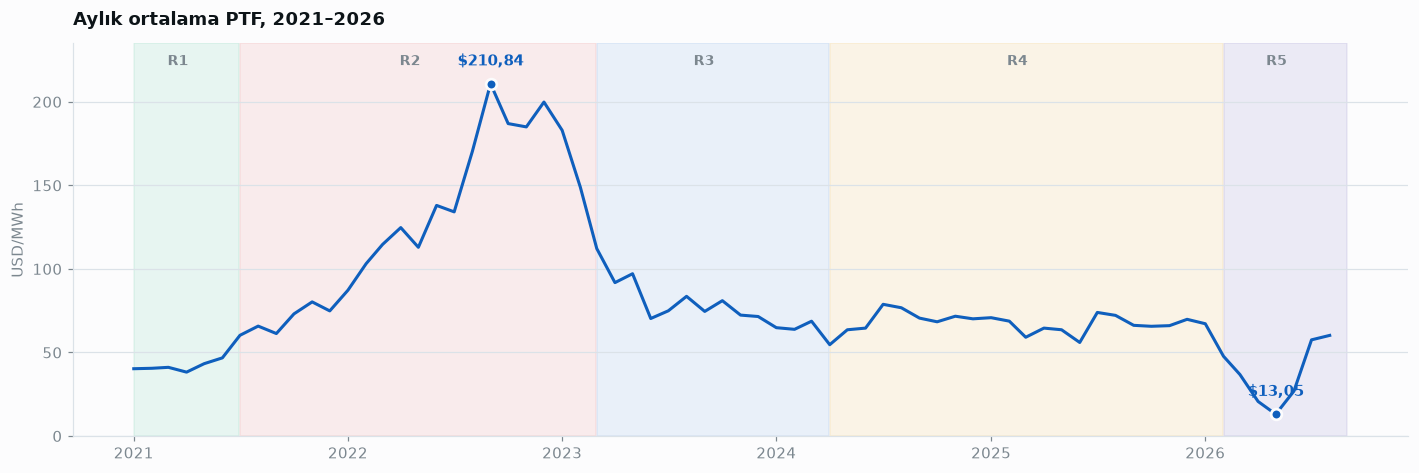

zirve : 2022-09  $210.84
dip   : 2026-05  $13.05
oran  : 16.2 kat


In [6]:
fig, ax = plt.subplots(figsize=(13, 4.4))

for rid, ad, bas, bit in REJIMLER:
    ax.axvspan(pd.Timestamp(bas + '-01'),
               pd.Timestamp(bit + '-01') + pd.offsets.MonthEnd(0),
               color=REJIM[rid], alpha=0.09, zorder=0)
    orta = pd.Timestamp(bas + '-01') + (pd.Timestamp(bit + '-01') - pd.Timestamp(bas + '-01')) / 2
    ax.text(orta, 222, rid, ha='center', color=INK3, fontsize=9, fontweight='bold')

ax.plot(aylik['ay_dt'], aylik['usd_ort'], color=ACCENT, lw=2, zorder=3)

for etiket in ('2022-09', '2026-05'):
    r = aylik[aylik['ay'] == etiket].iloc[0]
    ax.plot(r['ay_dt'], r['usd_ort'], 'o', color=ACCENT, ms=7,
            mec=YUZEY, mew=1.8, zorder=4)
    ax.annotate(f"${r['usd_ort']:.2f}".replace('.', ','),
                (r['ay_dt'], r['usd_ort']), textcoords='offset points',
                xytext=(0, 12), ha='center', color=ACCENT,
                fontsize=9.5, fontweight='bold')

ax.set_ylim(0, 235); ax.set_xlabel('')
duzen(ax, 'Aylık ortalama PTF, 2021–2026', 'USD/MWh')
plt.tight_layout(); plt.show()

print(f"zirve : {aylik.loc[aylik['usd_ort'].idxmax(), 'ay']}  "
      f"${aylik['usd_ort'].max():.2f}")
print(f"dip   : {aylik.loc[aylik['usd_ort'].idxmin(), 'ay']}  "
      f"${aylik['usd_ort'].min():.2f}")
print(f"oran  : {aylik['usd_ort'].max() / aylik['usd_ort'].min():.1f} kat")

> **Bulgu.** Zirve Eylül 2022'de \$210,84; dip Mayıs 2026'da \$13,05 — aralarında 16 kat var.
> TL bazında bakan biri 2021'den 2026'ya sürekli artış görür ve bu rejimlerin hiçbirini fark etmez.


## 3. Fiyatın sınıra dayandığı saatler

2022'yi analiz ederken sık yapılan hata, o dönemki fiyat hareketini piyasa sinyali
sanmaktır. Azami fiyat limitine yapışan saatlerin oranı bunun neden yanlış olduğunu gösterir.

**Kaynak: `silver.mcp_with_cap` — RESMÎ tavan serisi.** İlk sürüm tavanı aylık maksimumdan
istatistikle çıkarıyordu; artık gerek yok. EPİAŞ/EPDK azami fiyatı her ay duyuruyor ve haber
arşivi (`bronze.news_raw`) bu duyuruların hepsini içeriyor. Seri
`silver.price_cap_official`'de: 28 yürürlük kaydı, her satırın kaynak haberi kayıtlı,
**67 ayın 67'si doğrulanmış**.

Çıkarım yöntemi 24 ayda birebir tuttu ama iki yerde sessizce yanlıştı:

| Hata | Örnek | Etkisi |
|---|---|---|
| Tavan **ay ortasında** değişebiliyor | 2021-10-15: 718 → 1.078 | Ekim 2021 %8,1 yerine gerçekte **%22,6** |
| Fiyat tavana **hiç değmeyen** aylar | Şubat 2021: tavan 572, fiyat max 335 | O ay tavan devreye hiç girmedi |

**Serinin kör noktası — ve onun gerçekten ısırması.** Kayıt olmayan aylarda önceki değerin
devam ettiği varsayılıyor. Testi: *fiyat tavanı aşamaz* (48.000 saatte sıfır aşım). Ama bu
test kaçırılmış bir **düşüşü** göremiyor. Şubat 2023'te EPDK tavanı 4.200'den 3.650'ye
indirmişti (haber `52617`); ilk derlemede kaçırdım ve o ayın maksimumunu "piyasa zirvesi"
sandım. Kayıt eklenince oran %0'dan gerçek değeri olan %15,6'ya döndü.

Aşağıdaki hücre resmî seriyi ve iki yöntemin farkını gösteriyor.

In [7]:
RESMI_SERI = '''
SELECT effective_from, cap_try, source_article_id, note
FROM silver.price_cap_official ORDER BY effective_from
'''
print("RESMÎ TAVAN SERİSİ (haber arşivinden derlendi)")
display(q(RESMI_SERI))

FARK = '''
WITH resmi AS (
  SELECT date_trunc('month', ts AT TIME ZONE 'Europe/Istanbul') ay,
         COUNT(*) n, COUNT(*) FILTER (WHERE at_cap) atcap
  FROM silver.mcp_with_cap WHERE cap_try IS NOT NULL GROUP BY 1),
e AS (SELECT date_trunc('month', ts AT TIME ZONE 'Europe/Istanbul') ay, price_try p
      FROM public.raw_mcp_hourly),
mx AS (SELECT ay, MAX(p) m, COUNT(*) n FROM e GROUP BY 1),
eski AS (SELECT mx.ay, ROUND(100.0*COUNT(*) FILTER (WHERE e.p >= mx.m*0.999)/mx.n,1) pay
         FROM e JOIN mx ON mx.ay=e.ay GROUP BY mx.ay, mx.n)
SELECT to_char(r.ay,'YYYY-MM') ay,
       ROUND(100.0*r.atcap/r.n,1) resmi_pct, eski.pay AS eski_pct,
       ROUND(100.0*r.atcap/r.n,1) - eski.pay AS fark
FROM resmi r JOIN eski ON eski.ay=r.ay
WHERE ABS(ROUND(100.0*r.atcap/r.n,1) - eski.pay) >= 0.5 ORDER BY 1
'''
print("\nİKİ YÖNTEMİN FARK ETTİĞİ AYLAR")
display(q(FARK))

RESMÎ TAVAN SERİSİ (haber arşivinden derlendi)


,effective_from,cap_try,source_article_id,note
0,2021-02-01,572.0,41077,NaN
1,2021-03-01,569.0,41563,NaN
2,2021-04-01,567.0,42050,NaN
3,2021-05-01,578.0,42445,"haber ""11 TL arttı"" diyor: 567+11"
4,2021-06-01,595.0,42974,NaN
5,2021-07-01,617.0,43403,NaN
6,2021-08-01,636.0,43863,NaN
7,2021-09-01,674.0,44243,NaN
8,2021-10-01,718.0,44641,NaN
9,2021-10-15,1078.0,44932,AY ORTASI değişiklik; haber 728 TL diyor ama 4...



İKİ YÖNTEMİN FARK ETTİĞİ AYLAR


,ay,resmi_pct,eski_pct,fark
0,2021-10,22.6,8.1,14.5
1,2022-05,14.1,10.6,3.5
2,2023-07,3.0,1.5,1.5


In [8]:
sansur = aylik[(aylik['tavan_pct'] > 0.05) | (aylik['sifir_pct'] > 0.05)]
print('En yüksek tavan oranları:')
display(aylik.nlargest(6, 'tavan_pct')[['ay', 'try_ort', 'tavan_pct']])
print('\nEn yüksek sıfır fiyat oranları:')
display(aylik.nlargest(6, 'sifir_pct')[['ay', 'usd_ort', 'sifir_pct', 'ucuz_pct']])

En yüksek tavan oranları:


,ay,try_ort,tavan_pct
14,2022-03,1670.8,65.3
13,2022-02,1404.5,55.2
7,2021-08,557.4,52.6
6,2021-07,518.4,42.5
12,2022-01,1178.0,40.7
60,2026-01,2894.9,30.2



En yüksek sıfır fiyat oranları:


,ay,usd_ort,sifir_pct,ucuz_pct
64,2026-05,13.05,28.9,85.3
63,2026-04,20.66,13.2,66.9
65,2026-06,26.89,5.6,52.1
53,2025-06,55.99,4.3,14.6
62,2026-03,36.81,3.1,28.1
61,2026-02,47.73,3.0,13.4


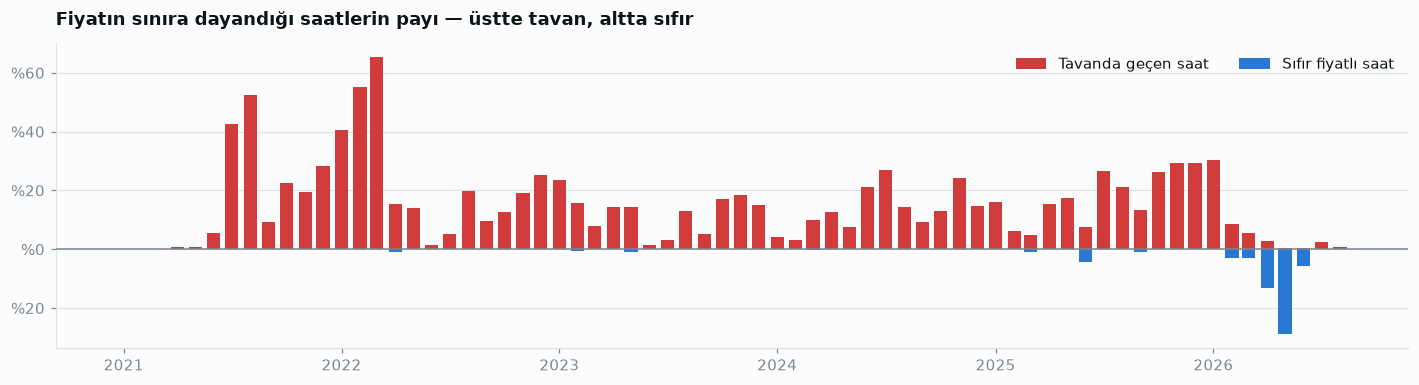

In [9]:
fig, ax = plt.subplots(figsize=(13, 3.6))
gen = 22  # gün cinsinden bar genişliği

ax.bar(aylik['ay_dt'], aylik['tavan_pct'], width=gen, color=POS,
       label='Tavanda geçen saat', zorder=3)
ax.bar(aylik['ay_dt'], -aylik['sifir_pct'], width=gen, color=NEG,
       label='Sıfır fiyatlı saat', zorder=3)

ax.axhline(0, color=INK3, lw=1, zorder=4)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'%{abs(v):.0f}'))
ax.legend(loc='upper right', ncol=2)
duzen(ax, 'Fiyatın sınıra dayandığı saatlerin payı — üstte tavan, altta sıfır')
plt.tight_layout(); plt.show()

> **Bulgu.** Mart 2022'de saatlerin **%65,3'ü** azami fiyat limitinde; fiyat fiziksel olarak
> yukarı çıkamıyordu. Dört yıl sonra aynı sıkışma ters uçta: Mayıs 2026'da saatlerin
> **%28,9'u** tam sıfır. İki uç da fiyatın piyasa sinyali taşımadığı bölge.
>
> **Sonucu:** o dönem için klasik bir olay çalışması ile "şokun fiyata etkisi" ölçülürse,
> etki sistematik olarak olduğundan _küçük_ çıkar — sansürlenmiş bağımlı değişken problemi.


## 4. Üretim kompozisyonu


In [10]:
MIX = '''
WITH g AS (
  SELECT date_trunc('month', ts AT TIME ZONE 'Europe/Istanbul') mo,
    AVG(total_mw) tot, AVG(solar_mw) sol, AVG(wind_mw) wnd,
    AVG(dammed_hydro_mw + river_hydro_mw) hyd,
    AVG(natural_gas_mw) gas,
    AVG(lignite_mw + import_coal_mw + black_coal_mw + asphaltite_coal_mw) coal,
    AVG(geothermal_mw + biomass_mw) must
  FROM public.raw_actual_generation_hourly GROUP BY 1),
p AS (SELECT date_trunc('month', ts AT TIME ZONE 'Europe/Istanbul') mo,
             AVG(price_usd) px FROM public.raw_mcp_hourly GROUP BY 1)
SELECT to_char(g.mo, 'YYYY-MM') ay, ROUND(g.tot) toplam_mw,
  ROUND(p.px::numeric, 1) fiyat_usd,
  ROUND((100*g.hyd/g.tot)::numeric, 1)  hidro,
  ROUND((100*g.wnd/g.tot)::numeric, 1)  ruzgar,
  ROUND((100*g.sol/g.tot)::numeric, 1)  gunes,
  ROUND((100*g.must/g.tot)::numeric, 1) diger,
  ROUND((100*g.gas/g.tot)::numeric, 1)  gaz,
  ROUND((100*g.coal/g.tot)::numeric, 1) komur,
  ROUND((100*(g.tot-(g.sol+g.wnd+g.hyd+g.must))/g.tot)::numeric, 1) termal_pay
FROM g JOIN p ON p.mo = g.mo ORDER BY 1
'''
mix = q(MIX)
mix['ay_dt'] = pd.to_datetime(mix['ay'])
mix.tail(8)

,ay,toplam_mw,fiyat_usd,hidro,ruzgar,gunes,diger,gaz,komur,termal_pay,ay_dt
60,2026-01,40630.0,67.2,14.0,17.2,1.1,5.5,26.7,36.3,62.1,2026-01-01
61,2026-02,38301.0,47.7,31.9,15.7,1.5,5.9,10.2,35.1,45.0,2026-02-01
62,2026-03,35442.0,36.8,40.1,13.8,2.3,6.3,7.7,30.3,37.5,2026-03-01
63,2026-04,33694.0,20.7,47.9,11.0,2.7,6.4,8.7,23.7,32.1,2026-04-01
64,2026-05,31156.0,13.0,50.4,10.2,2.7,6.6,11.6,18.9,30.1,2026-05-01
65,2026-06,35312.0,26.9,41.3,13.3,3.8,5.6,10.0,26.3,35.9,2026-06-01
66,2026-07,40476.0,57.6,30.1,13.6,3.9,4.8,11.5,36.0,47.6,2026-07-01
67,2026-08,42203.0,60.2,28.2,17.7,3.6,4.6,11.9,35.7,45.9,2026-08-01


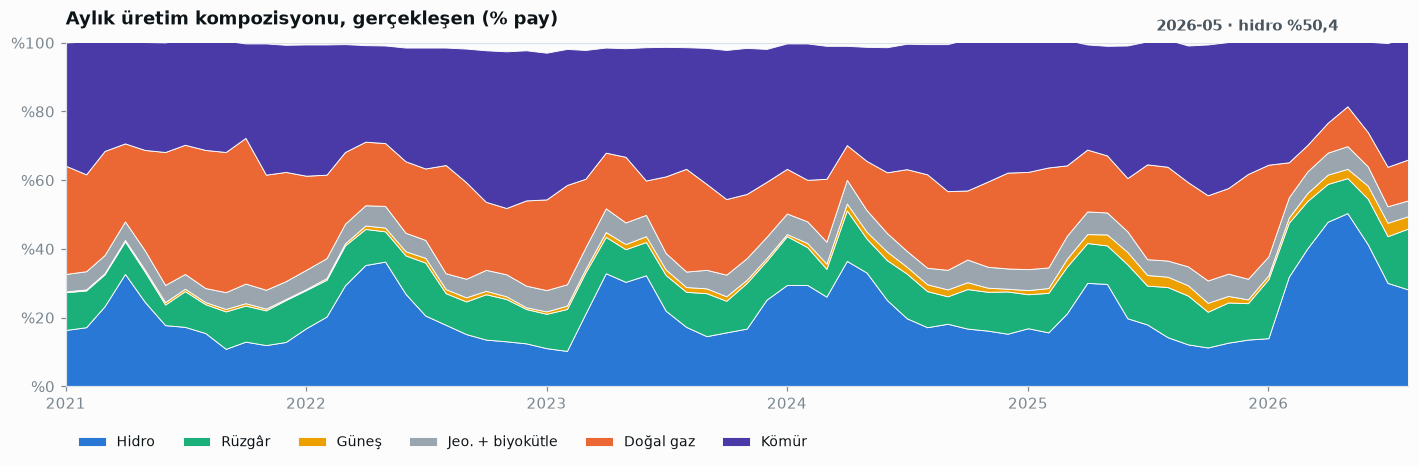

In [11]:
fig, ax = plt.subplots(figsize=(13, 4.4))
sira = ['hidro', 'ruzgar', 'gunes', 'diger', 'gaz', 'komur']
adlar = ['Hidro', 'Rüzgâr', 'Güneş', 'Jeo. + biyokütle', 'Doğal gaz', 'Kömür']

ax.stackplot(mix['ay_dt'], *[mix[k] for k in sira],
             labels=adlar, colors=[KAYNAK[k] for k in sira],
             edgecolor=YUZEY, linewidth=0.6)

r = mix[mix['ay'] == '2026-05'].iloc[0]
ax.annotate(f"2026-05 · hidro %{r['hidro']:.1f}".replace('.', ','),
            (r['ay_dt'], 100), textcoords='offset points', xytext=(-6, 8),
            ha='right', color=INK2, fontsize=9.5, fontweight='bold')

ax.set_ylim(0, 100); ax.set_xlim(mix['ay_dt'].min(), mix['ay_dt'].max())
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'%{v:.0f}'))
ax.legend(loc='lower left', ncol=6, bbox_to_anchor=(0, -0.22), fontsize=9)
duzen(ax, 'Aylık üretim kompozisyonu, gerçekleşen (% pay)')
plt.tight_layout(); plt.show()

In [12]:
# 2025-05 ve 2026-05 — aynı mevsim, farklı yıl
kars = mix[mix['ay'].isin(['2025-05', '2026-05'])].set_index('ay')
kars = kars[['fiyat_usd', 'gunes', 'ruzgar', 'hidro', 'gaz', 'komur', 'termal_pay']].T
kars['fark'] = (kars['2026-05'] - kars['2025-05']).round(1)
kars

ay,2025-05,2026-05,fark
fiyat_usd,63.6,13.0,-50.6
gunes,3.2,2.7,-0.5
ruzgar,11.2,10.2,-1.0
hidro,29.8,50.4,20.6
gaz,16.6,11.6,-5.0
komur,31.9,18.9,-13.0
termal_pay,49.4,30.1,-19.3


> **Bulgu.** 2026 baharındaki çöküş **güneş kaynaklı değil**. Güneşin payı %3,2 → %2,7'ye
> _düştü_, rüzgâr %11,2 → %10,2'ye düştü. Tek başına hidro +20,6 puan arttı (%29,8 → %50,4)
> ve fiyat \$63,6'dan \$13,0'a indi. Bu bir mevsimsellik olayı da değil — 2025 baharında
> aynı çöküş yok.


## 5. Hangi büyüklük yıllar arasında taşınıyor?

Bir değişkenin tahmin modelinde kullanılabilir olması için, o değişken ile fiyat arasındaki
ilişkinin yıllar arasında sabit kalması gerekir. Aksi halde model geçmişten doğru bir şey
öğrenir ve gelecekte yanılır.

Aşağıdaki iki sorgu tam olarak bunu test ediyor: **aynı bandı farklı yıllarda** karşılaştırır.


In [13]:
BANT = '''
WITH h AS (
  SELECT EXTRACT(year FROM g.ts AT TIME ZONE 'Europe/Istanbul')::int yil,
         m.price_usd px,
         100.0 * (g.dammed_hydro_mw + g.river_hydro_mw) / NULLIF(g.total_mw, 0) hidro_pay,
         100.0 * (g.total_mw - (g.solar_mw + g.wind_mw + g.dammed_hydro_mw
                  + g.river_hydro_mw + g.geothermal_mw + g.biomass_mw))
                 / NULLIF(g.total_mw, 0) termal_pay
  FROM public.raw_actual_generation_hourly g
  JOIN public.raw_mcp_hourly m ON m.ts = g.ts
  WHERE g.ts >= '2023-01-01')
SELECT yil, px, hidro_pay, termal_pay FROM h
'''
bant = q(BANT)
print(f'{len(bant):,} saat')

def bantla(df, kolon, kenarlar):
    """Sürekli değişkeni banda böl, yıl × bant ortalama fiyat tablosu üret."""
    etiket = [f'{a}–{b}%' for a, b in zip(kenarlar[:-1], kenarlar[1:])]
    d = df.copy()
    d['bant'] = pd.cut(d[kolon], bins=kenarlar, labels=etiket)
    piv = d.pivot_table(index='bant', columns='yil', values='px',
                        aggfunc='mean', observed=False).round(1)
    say = d.pivot_table(index='bant', columns='yil', values='px',
                        aggfunc='size', observed=False)
    return piv, say

hidro_piv, hidro_n = bantla(bant, 'hidro_pay', [10, 20, 30, 40, 50, 60])
termal_piv, termal_n = bantla(bant, 'termal_pay', [20, 30, 40, 50, 60, 70, 100])

print('\nHİDRO PAYI → ortalama fiyat ($/MWh)'); display(hidro_piv)
print('gözlem sayısı'); display(hidro_n)

31,779 saat

HİDRO PAYI → ortalama fiyat ($/MWh)


yil,2023,2024,2025,2026
bant,,,,
10–20%,98.3,68.6,66.8,59.5
20–30%,88.4,70.3,67.4,48.5
30–40%,83.1,65.3,71.7,41.4
40–50%,83.6,68.8,79.8,28.2
50–60%,58.8,69.6,NaN,29.1


gözlem sayısı


yil,2023,2024,2025,2026
bant,,,,
10–20%,3513,3212,3532,472
20–30%,2623,2832,2277,1089
30–40%,1422,2034,889,1553
40–50%,171,249,24,1217
50–60%,7,8,0,830


In [14]:
print('TERMAL İHTİYAÇ ORANI → ortalama fiyat ($/MWh)'); display(termal_piv)
print('gözlem sayısı'); display(termal_n)

TERMAL İHTİYAÇ ORANI → ortalama fiyat ($/MWh)


yil,2023,2024,2025,2026
bant,,,,
20–30%,28.1,32.7,26.1,12.3
30–40%,48.3,40.0,32.3,29.8
40–50%,76.1,59.6,49.7,46.3
50–60%,85.7,70.1,66.1,65.2
60–70%,96.9,74.8,71.5,70.6
70–100%,129.1,73.4,71.5,70.1


gözlem sayısı


yil,2023,2024,2025,2026
bant,,,,
20–30%,3,158,21,856
30–40%,220,445,270,1875
40–50%,1255,1438,901,1355
50–60%,2459,2881,2475,869
60–70%,2908,2830,3238,350
70–100%,1915,1031,1855,123


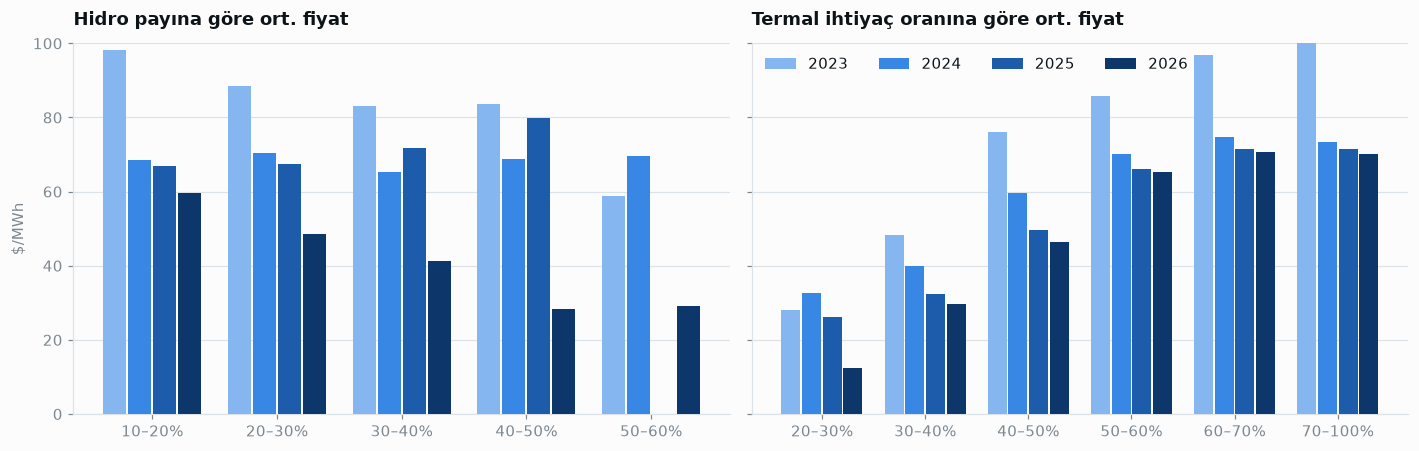

hidro payı   bant içi yıllar arası ort. değişim katsayısı: 0.306
termal pay   bant içi yıllar arası ort. değişim katsayısı: 0.239


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
yillar = [2023, 2024, 2025, 2026]

for ax, piv, baslik in zip(
        axes, [hidro_piv, termal_piv],
        ['Hidro payına göre ort. fiyat', 'Termal ihtiyaç oranına göre ort. fiyat']):
    x = np.arange(len(piv.index)); g = 0.2
    for i, yil in enumerate(yillar):
        if yil not in piv.columns: continue
        ax.bar(x + (i - 1.5) * g, piv[yil], g * 0.92, label=str(yil),
               color=ORD4[i], zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(piv.index)
    duzen(ax, baslik)

axes[0].set_ylabel('$/MWh'); axes[0].set_ylim(0, 100)
axes[1].legend(title='', ncol=4, loc='upper left')
plt.tight_layout(); plt.show()

# taşınabilirlik ölçüsü: bant içi yıllar arası değişim katsayısı
for ad, piv in [('hidro payı', hidro_piv), ('termal pay', termal_piv)]:
    cv = (piv.std(axis=1) / piv.mean(axis=1)).mean()
    print(f'{ad:12s} bant içi yıllar arası ort. değişim katsayısı: {cv:.3f}')

> **Bulgu — raporun en önemli sonucu.**
>
> **Solda:** aynı hidro payı yıldan yıla bambaşka fiyat üretiyor. %40–50 bandında 2025'te
> ortalama \$79,8, 2026'da \$28,2 — **2,8 kat fark**.
>
> **Sağda:** aynı termal ihtiyaç oranı her yıl neredeyse aynı fiyatı üretiyor. %60–70
> bandında 2024/2025/2026 sırasıyla \$74,8 / \$71,5 / \$70,6.
>
> **Neden:** 2023–2025'te hidro yüksek olduğunda fiyat düşmüyordu, çünkü gaz hâlâ marjinal
> santraldi — hidro sadece gazın _bir kısmının_ yerini alıyordu. 2026'da hidro o kadar
> büyüdü ki marjinal santralin kendisi değişti. Yani "hidro payı → fiyat" ilişkisi
> **koşullu**; "termal pay → fiyat" ilişkisi doğrudan.
>
> **Modele etkisi:** hidro payını feature olarak vermek, modele yıllar arasında
> geçersizleşen bir kural öğretir. Ayrıca **destek sorunu** var: %40–50 hidro bandında
> 2023–2025 toplamı 24 saat, 2026 tek başına 1.217 saat — model o bölgeyi hiç görmemişti.


## 6. Plato neden $70?

Yüksek termal paylı saatlerde fiyat 2024–2026 boyunca \$70–75 bandında oturuyor. Bu
seviyenin nereden geldiği **elektrik verisine hiç bakmadan** hesaplanabilir: BOTAŞ'ın gaz
referans fiyatından.

1.000 Sm³ doğal gaz ≈ 9,59 MWh ısıl enerji (alt ısıl değer). Kombine çevrim santralinin
net verimi ~%53 alınırsa, örtük elektrik maliyeti `GRF ÷ 9,59 ÷ 0,53`.


In [16]:
GAZ = '''
WITH gaz AS (
  SELECT EXTRACT(year FROM entry_date)::int yil, AVG(grf_usd) grf
  FROM public.raw_natural_gas_daily GROUP BY 1),
yt AS (
  SELECT EXTRACT(year FROM g.ts AT TIME ZONE 'Europe/Istanbul')::int yil,
         AVG(m.price_usd) px_yuksek_termal, COUNT(*) n
  FROM public.raw_actual_generation_hourly g
  JOIN public.raw_mcp_hourly m ON m.ts = g.ts
  WHERE 100.0 * (g.total_mw - (g.solar_mw + g.wind_mw + g.dammed_hydro_mw
        + g.river_hydro_mw + g.geothermal_mw + g.biomass_mw)) / NULLIF(g.total_mw,0) >= 60
  GROUP BY 1),
hepsi AS (
  SELECT EXTRACT(year FROM ts AT TIME ZONE 'Europe/Istanbul')::int yil,
         AVG(price_usd) ptf_ort FROM public.raw_mcp_hourly GROUP BY 1)
SELECT g.yil, ROUND(g.grf::numeric, 1) grf_usd_1000sm3,
       ROUND(h.ptf_ort::numeric, 1) ptf_yil_ort,
       ROUND(y.px_yuksek_termal::numeric, 1) ptf_yuksek_termal, y.n saat
FROM gaz g JOIN hepsi h ON h.yil = g.yil JOIN yt y ON y.yil = g.yil
ORDER BY 1
'''
gaz = q(GAZ)

MWH_PER_1000SM3 = 9.59   # alt ısıl değer
VERIM = 0.53             # kombine çevrim net verimi (varsayım)

gaz['isil_maliyet'] = (gaz['grf_usd_1000sm3'] / MWH_PER_1000SM3).round(1)
gaz['ortuk_kc_maliyeti'] = (gaz['isil_maliyet'] / VERIM).round(1)
gaz['fark'] = (gaz['ptf_yuksek_termal'] - gaz['ortuk_kc_maliyeti']).round(1)

display(gaz[['yil', 'grf_usd_1000sm3', 'isil_maliyet', 'ortuk_kc_maliyeti',
             'ptf_yuksek_termal', 'fark', 'saat']])

kor = gaz['ortuk_kc_maliyeti'].corr(gaz['ptf_yuksek_termal'])
print(f'\nÖrtük maliyet ↔ gerçekleşen fiyat korelasyonu: {kor:.3f}')
print(f'2026 farkı: ${gaz.iloc[-1]["fark"]:+.1f}/MWh')

,yil,grf_usd_1000sm3,isil_maliyet,ortuk_kc_maliyeti,ptf_yuksek_termal,fark,saat
0,2021,267.5,27.9,52.6,58.6,6.0,7120
1,2022,927.7,96.7,182.5,168.9,-13.6,4801
2,2023,464.9,48.5,91.5,109.7,18.2,4823
3,2024,340.2,35.5,67.0,74.4,7.4,3861
4,2025,348.1,36.3,68.5,71.5,3.0,5093
5,2026,357.6,37.3,70.4,70.5,0.1,473



Örtük maliyet ↔ gerçekleşen fiyat korelasyonu: 0.982
2026 farkı: $+0.1/MWh


> **Bulgu.** Son üç yılda iki sütun birbirini izliyor; 2026'da \$70,4'e karşı \$70,5.
> 2023'teki sapma, o yıl kömürün de sık sık marjinal santral olmasıyla tutarlı.
>
> Hesap ne karbon maliyetini, ne devreye alma maliyetini, ne de santral bazında verim
> farklarını içeriyor; buna rağmen platonun seviyesini **tek bir dışsal fiyattan** açıklıyor.
>
> **Analitik sonucu:** plato dönemlerinde "fiyat nereye gider" sorusunun cevabı elektrik
> piyasasında değil, gaz tarafında. Rejim kırıldığında bu bağ kopuyor.


## 7. Sürücülerin ağırlığı yıldan yıla değişiyor

Tek bir "fiyat modeli hikâyesi" yok; rejime göre değişen bir yapı var.


In [17]:
SURUCU = '''
WITH d AS (
  SELECT (m.ts AT TIME ZONE 'Europe/Istanbul')::date gun,
    EXTRACT(year FROM m.ts AT TIME ZONE 'Europe/Istanbul')::int yil,
    AVG(m.price_usd) px, AVG(c.consumption_mw) talep,
    AVG(100.0*(g.total_mw-(g.solar_mw+g.wind_mw+g.dammed_hydro_mw+g.river_hydro_mw
        +g.geothermal_mw+g.biomass_mw))/NULLIF(g.total_mw,0)) termal_pay,
    AVG(100.0*(g.dammed_hydro_mw+g.river_hydro_mw)/NULLIF(g.total_mw,0)) hidro_pay,
    AVG(100.0*(g.solar_mw+g.wind_mw)/NULLIF(g.total_mw,0)) gunes_ruzgar
  FROM public.raw_mcp_hourly m
  JOIN public.raw_actual_generation_hourly g ON g.ts = m.ts
  JOIN public.raw_actual_consumption_hourly c ON c.ts = m.ts
  GROUP BY 1, 2)
SELECT d.*, mac.usd_try, mac.brent_oil_usd
FROM d LEFT JOIN public.raw_macro_daily mac ON mac.entry_date = d.gun
ORDER BY 1
'''
sur = q(SURUCU)

kolonlar = ['termal_pay', 'hidro_pay', 'gunes_ruzgar', 'talep', 'brent_oil_usd', 'usd_try']
korr = (sur.groupby('yil')[['px'] + kolonlar]
        .apply(lambda d: d[kolonlar].corrwith(d['px']))
        .round(3))
korr.columns = ['Termal ihtiyaç oranı', 'Hidro payı', 'Güneş + rüzgâr payı',
                'Talep', 'Brent', 'USD/TRY']
korr

,Termal ihtiyaç oranı,Hidro payı,Güneş + rüzgâr payı,Talep,Brent,USD/TRY
yil,,,,,,
2021,0.575,-0.540,-0.077,0.389,0.773,0.587
2022,0.663,-0.546,-0.344,0.162,-0.315,0.789
2023,0.530,-0.468,-0.257,0.021,0.070,-0.672
2024,0.756,-0.435,-0.607,0.760,-0.264,0.236
2025,0.636,-0.283,-0.542,0.681,0.043,0.072
2026,0.896,-0.801,-0.019,0.739,-0.641,-0.084


> **Üç okuma.**
> **(1)** Termal ihtiyaç oranı altı yılın hepsinde en güçlü tek değişken, 2026'da 0,896.
> **(2)** Talebin fiyatla ilişkisi 2021–2023'te zayıf (0,02–0,39), 2024 sonrası güçlü
> (0,68–0,76) — kriz yıllarında fiyatı talep değil yakıt maliyeti sürüyordu.
> **(3)** Güneş ve rüzgârın 2026 korelasyonu 0'a düşmüş görünüyor; bu onların etkisiz olduğu
> anlamına gelmiyor, o yıl hidronun her şeyi domine ettiği anlamına geliyor.


## 8. Gün içi şekil — ördek eğrisi

Rejim tartışması fiyat seviyesi üzerinden yürüyor, ama bir portföy için asıl değişen şey
_gün içi şekil_. Aşağıda her saatin fiyatı o günün ortalamasına oranlanıyor; böylece seviye
etkisi çıkıyor, geriye sadece şekil kalıyor.

2022 dışlandı — tavan rejimi şekli bozuyor.


In [18]:
DUCK = '''
WITH d AS (
  SELECT (ts AT TIME ZONE 'Europe/Istanbul')::date gun, AVG(price_usd) gun_ort
  FROM public.raw_mcp_hourly
  WHERE EXTRACT(month FROM ts AT TIME ZONE 'Europe/Istanbul') IN (7, 8)
  GROUP BY 1)
SELECT EXTRACT(year FROM m.ts AT TIME ZONE 'Europe/Istanbul')::int yil,
       EXTRACT(hour FROM m.ts AT TIME ZONE 'Europe/Istanbul')::int saat,
       AVG(m.price_usd / NULLIF(d.gun_ort, 0)) oran
FROM public.raw_mcp_hourly m
JOIN d ON d.gun = (m.ts AT TIME ZONE 'Europe/Istanbul')::date
WHERE EXTRACT(month FROM m.ts AT TIME ZONE 'Europe/Istanbul') IN (7, 8)
GROUP BY 1, 2 ORDER BY 1, 2
'''
duck = q(DUCK).pivot(index='saat', columns='yil', values='oran').round(3)
duck = duck[[2021, 2023, 2024, 2025, 2026]]
duck

yil,2021,2023,2024,2025,2026
saat,,,,,
0,1.097,1.111,1.131,1.137,1.310
1,1.032,1.029,1.076,1.119,1.180
2,0.907,0.955,1.004,1.079,1.079
3,0.850,0.905,0.953,1.072,1.124
4,0.836,0.897,0.952,1.054,1.147
5,0.767,0.863,0.935,1.038,1.088
6,0.712,0.848,0.845,1.008,0.990
7,0.749,0.757,0.733,0.871,0.583
8,0.920,0.995,1.004,0.985,0.851


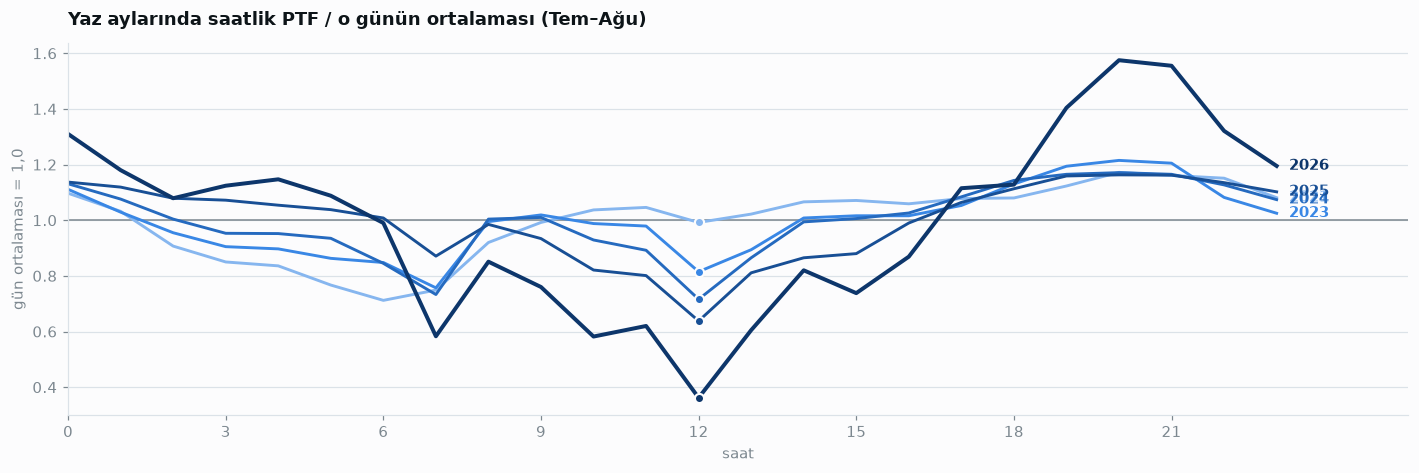

Öğle (12:00) ve akşam zirvesi (20:00) oranları:
saat  ogle_12  aksam_20
yil                    
2021    0.992     1.172
2023    0.815     1.215
2024    0.716     1.171
2025    0.638     1.163
2026    0.362     1.575


In [19]:
fig, ax = plt.subplots(figsize=(13, 4.4))

for renk, yil in zip(ORD5, duck.columns):
    lw = 2.6 if yil == 2026 else 1.9
    ax.plot(duck.index, duck[yil], color=renk, lw=lw, label=str(yil))
    ax.plot(12, duck.loc[12, yil], 'o', color=renk, ms=6, mec=YUZEY, mew=1.4)
    ax.annotate(str(yil), (23, duck.loc[23, yil]), textcoords='offset points',
                xytext=(8, 0), va='center', color=renk, fontsize=9.5, fontweight='bold')

ax.axhline(1.0, color=INK3, lw=1, zorder=1)
ax.set_xticks(range(0, 24, 3)); ax.set_xlim(0, 25.5)
ax.set_xlabel('saat')
duzen(ax, 'Yaz aylarında saatlik PTF / o günün ortalaması (Tem–Ağu)', 'gün ortalaması = 1,0')
plt.tight_layout(); plt.show()

print('Öğle (12:00) ve akşam zirvesi (20:00) oranları:')
print(duck.loc[[12, 20]].T.rename(columns={12: 'ogle_12', 20: 'aksam_20'}))

In [20]:
MAKAS = '''
WITH d AS (
  SELECT (ts AT TIME ZONE 'Europe/Istanbul')::date gun,
         EXTRACT(year FROM ts AT TIME ZONE 'Europe/Istanbul')::int yil,
         MAX(price_usd) mx, MIN(price_usd) mn, AVG(price_usd) av
  FROM public.raw_mcp_hourly GROUP BY 1, 2)
SELECT yil, COUNT(*) gun_sayisi,
  ROUND(AVG(mx - mn)::numeric, 1) ort_makas_usd,
  ROUND(AVG(CASE WHEN mn > 1 THEN mx / mn END)::numeric, 1) ort_max_bolu_min,
  ROUND((100.0 * AVG((mn <= 0.01)::int))::numeric, 1) sifir_gorulen_gun_pct
FROM d GROUP BY 1 ORDER BY 1
'''
q(MAKAS)

,yil,gun_sayisi,ort_makas_usd,ort_max_bolu_min,sifir_gorulen_gun_pct
0,2021,365,27.3,2.0,0.0
1,2022,365,94.7,4.0,0.3
2,2023,365,64.6,3.2,0.5
3,2024,366,47.4,3.9,0.5
4,2025,365,48.7,4.7,2.7
5,2026,229,62.5,9.8,25.3


> **Bulgu.** Yaz öğle saatinde fiyat 2021'de gün ortalamasıyla neredeyse aynıydı (0,99);
> 2026'da ortalamanın **%36'sı** (0,36). Akşam zirvesi aynı dönemde 1,17'den 1,58'e çıktı.
> Ortalama gün içi makas 2,0 kattan **9,8 kata** genişledi ve 2026'da günlerin %25,3'ünde
> en az bir saat sıfır fiyat görüldü (2021'de %0).
>
> Bu, güneşin gün ortasında merit-order'ı aşağı itmesinin doğrudan izi — ördek eğrisinin
> Türkiye versiyonu.


## 9. Lisanssız güneş: ölçüm boşluğu

Güneşin fiyat üzerindeki etkisi, üretim verisinde göründüğünden büyük. Sebebi kapasitenin
nerede kurulu olduğu.


In [21]:
KAPASITE = '''
SELECT EXTRACT(year FROM period_date)::int yil, energy_type tip,
  ROUND(AVG(licensed_capacity_mw))   lisansli_mw,
  ROUND(AVG(unlicensed_capacity_mw)) lisanssiz_mw,
  ROUND(AVG(total_capacity_mw))      toplam_mw
FROM public.raw_installed_capacity_daily
WHERE energy_type IN ('Güneş', 'Rüzgar')
GROUP BY 1, 2 ORDER BY 2, 1
'''
kap = q(KAPASITE)

URETIM = '''
SELECT EXTRACT(year FROM ts AT TIME ZONE 'Europe/Istanbul')::int yil,
  ROUND(MAX(solar_mw)) max_gunes_mw, ROUND(MAX(wind_mw)) max_ruzgar_mw
FROM public.raw_actual_generation_hourly GROUP BY 1 ORDER BY 1
'''
ure = q(URETIM)

gunes = kap[kap['tip'] == 'Güneş'].merge(ure[['yil', 'max_gunes_mw']], on='yil')
gunes['gorunurluk_pct'] = (100 * gunes['max_gunes_mw'] / gunes['toplam_mw']).round(1)
gunes['lisanssiz_pct'] = (100 * gunes['lisanssiz_mw'] / gunes['toplam_mw']).round(1)
print('GÜNEŞ')
display(gunes[['yil', 'lisansli_mw', 'lisanssiz_mw', 'toplam_mw',
               'lisanssiz_pct', 'max_gunes_mw', 'gorunurluk_pct']])

ruz = kap[kap['tip'] == 'Rüzgar'].merge(ure[['yil', 'max_ruzgar_mw']], on='yil')
ruz['gorunurluk_pct'] = (100 * ruz['max_ruzgar_mw'] / ruz['toplam_mw']).round(1)
print('\nRÜZGÂR — karşılaştırma için')
display(ruz[['yil', 'lisansli_mw', 'lisanssiz_mw', 'toplam_mw',
             'max_ruzgar_mw', 'gorunurluk_pct']])

GÜNEŞ


,yil,lisansli_mw,lisanssiz_mw,toplam_mw,lisanssiz_pct,max_gunes_mw,gorunurluk_pct
0,2021,648.0,6466.0,7114.0,90.9,764.0,10.7
1,2022,1204.0,7338.0,8542.0,85.9,1290.0,15.1
2,2023,1469.0,8643.0,10112.0,85.5,1547.0,15.3
3,2024,1469.0,11185.0,12654.0,88.4,2226.0,17.6
4,2025,1469.0,18576.0,20045.0,92.7,3394.0,16.9
5,2026,1469.0,22873.0,24342.0,94.0,4137.0,17.0



RÜZGÂR — karşılaştırma için


,yil,lisansli_mw,lisanssiz_mw,toplam_mw,max_ruzgar_mw,gorunurluk_pct
0,2021,7906.0,52.0,7958.0,8478.0,106.5
1,2022,8779.0,55.0,8834.0,9328.0,105.6
2,2023,7908.0,60.0,7968.0,9738.0,122.2
3,2024,7204.0,71.0,7275.0,10079.0,138.5
4,2025,8003.0,128.0,8130.0,10612.0,130.5
5,2026,8273.0,164.0,8437.0,12060.0,142.9


### Talep bastırma testi

Lisanssız üretim talebi düşürüyorsa, tüketim profilinin yıllar içinde öğle saatlerinde
bastırılması gerekir. Hipotezi test edelim.


In [22]:
TUKETIM = '''
WITH d AS (
  SELECT (ts AT TIME ZONE 'Europe/Istanbul')::date gun, AVG(consumption_mw) gun_ort
  FROM public.raw_actual_consumption_hourly
  WHERE EXTRACT(month FROM ts AT TIME ZONE 'Europe/Istanbul') IN (6, 7, 8)
  GROUP BY 1)
SELECT EXTRACT(year FROM c.ts AT TIME ZONE 'Europe/Istanbul')::int yil,
       EXTRACT(hour FROM c.ts AT TIME ZONE 'Europe/Istanbul')::int saat,
       AVG(c.consumption_mw / NULLIF(d.gun_ort, 0)) oran
FROM public.raw_actual_consumption_hourly c
JOIN d ON d.gun = (c.ts AT TIME ZONE 'Europe/Istanbul')::date
WHERE EXTRACT(month FROM c.ts AT TIME ZONE 'Europe/Istanbul') IN (6, 7, 8)
GROUP BY 1, 2 ORDER BY 1, 2
'''
tuk = q(TUKETIM).pivot(index='saat', columns='yil', values='oran').round(3)
print('Yaz aylarında saatlik tüketim / gün ortalaması, öğle saatleri:')
display(tuk.loc[10:13])

print('\nSaat 11:00 oranı yıllara göre:')
print(tuk.loc[11].round(3).to_string())
print(f"\n2021 → 2026 değişim: {(tuk.loc[11, 2026] - tuk.loc[11, 2021]):+.3f}")

Yaz aylarında saatlik tüketim / gün ortalaması, öğle saatleri:


yil,2021,2022,2023,2024,2025,2026
saat,,,,,,
10,1.084,1.086,1.069,1.071,1.056,1.082
11,1.114,1.114,1.098,1.104,1.086,1.107
12,1.097,1.094,1.080,1.093,1.076,1.090
13,1.114,1.110,1.097,1.113,1.098,1.109



Saat 11:00 oranı yıllara göre:
yil
2021    1.114
2022    1.114
2023    1.098
2024    1.104
2025    1.086
2026    1.107

2021 → 2026 değişim: -0.007


> **Bulgu — ve doğrulanmayan hipotez.**
>
> Ağustos 2026 itibarıyla güneşte kurulu gücün **%94'ü lisanssız** (23.687 / 25.156 MW).
> Rüzgârda tablo tam tersi. Raporlanan saatlik güneş üretimi kurulu gücün ancak altıda
> birine çıkıyor.
>
> Ama talep bastırma testi hipotezi **net biçimde doğrulamıyor**: saat 11:00'deki
> tüketim/gün ortalaması oranı yıllar içinde anlamlı ölçüde düşmüyor.
>
> Bunu böyle raporlamak gerekiyor. Sistem tüketiminin nerede ölçüldüğüne bağlı olarak bu
> beklenen bir sonuç olabilir; ayrıştırmak için dağıtım seviyesi veri gerekiyor ve elimizde
> yok. **25 GW'lık bir kaynağın piyasa verisindeki izinin belirsiz olması**, üzerine model
> kurulan her analiz için bilinmesi gereken bir sınır.


## 10. Model performansı — çekirdek metrik seti

**Naive baseline** (Lago et al. 2021 standardı): Pazartesi, Cumartesi ve Pazar için geçen
haftanın aynı saati; Salı–Cuma için dünün aynı saati.

`rMAE = MAE_model / MAE_naive`. Rejimden bağımsız ve literatürle kıyaslanabilir tek metrik.
İyi elektrik fiyat modelleri kabaca 0,5–0,8 bandında.


In [23]:
MODEL = '''
WITH b AS (
  SELECT p.target_ts, m.price_usd px, p.predicted_mcp_usd pred,
         p.predicted_mcp_usd_p10 p10, p.predicted_mcp_usd_p90 p90,
         EXTRACT(dow FROM p.target_ts AT TIME ZONE 'Europe/Istanbul') dow,
         n1.price_usd nv1, n7.price_usd nv7
  FROM gold.ptf_predictions_daily p
  JOIN public.raw_mcp_hourly m  ON m.ts  = p.target_ts
  LEFT JOIN public.raw_mcp_hourly n1 ON n1.ts = p.target_ts - INTERVAL '1 day'
  LEFT JOIN public.raw_mcp_hourly n7 ON n7.ts = p.target_ts - INTERVAL '7 day')
SELECT target_ts, px, pred, p10, p90,
       CASE WHEN dow IN (1,6,0) THEN nv7 ELSE nv1 END naive
FROM b
'''
mdl = q(MODEL).dropna(subset=['naive'])
mdl['target_ts'] = pd.to_datetime(mdl['target_ts'], utc=True).dt.tz_convert('Europe/Istanbul')
mdl['ay'] = mdl['target_ts'].dt.strftime('%Y-%m')
for c in ['px', 'pred', 'p10', 'p90', 'naive']:
    mdl[c] = mdl[c].astype(float)
print(f'{len(mdl):,} saat  |  {mdl["ay"].min()} → {mdl["ay"].max()}')

17,592 saat  |  2024-08 → 2026-08


In [24]:
def metrikler(d):
    """Çekirdek metrik seti — hiçbir model kararı tek metriğe dayanmaz."""
    hata = d['pred'] - d['px']
    nhata = d['naive'] - d['px']
    return pd.Series({
        'n': len(d),
        'ort_fiyat': d['px'].mean(),
        'MAE': hata.abs().mean(),
        'BIAS': hata.mean(),
        'naive_MAE': nhata.abs().mean(),
        'rMAE': hata.abs().mean() / nhata.abs().mean(),
        'sMAPE%': 100 * (2 * hata.abs() / (d['pred'].abs() + d['px'].abs())).mean(),
        'WAPE%': 100 * hata.abs().sum() / d['px'].sum(),
        'kapsama%': 100 * ((d['px'] >= d['p10']) & (d['px'] <= d['p90'])).mean(),
    })

def donem(ay):
    if ay < '2026-02': return '1 Durağan (2024-08→2026-01)'
    if ay < '2026-07': return '2 Kriz (2026-02→06)'
    return '3 Toparlanma (2026-07→08)'

mdl['donem'] = mdl['ay'].map(donem)

tablo = mdl.groupby('donem').apply(metrikler, include_groups=False)
tablo.loc['4 TÜMÜ'] = metrikler(mdl)
tablo['n'] = tablo['n'].astype(int)
tablo.round(3)

,n,ort_fiyat,MAE,BIAS,naive_MAE,rMAE,sMAPE%,WAPE%,kapsama%
donem,,,,,,,,,
1 Durağan (2024-08→2026-01),12912,67.690,6.229,0.889,8.562,0.728,13.575,9.202,75.132
2 Kriz (2026-02→06),3528,28.957,10.541,3.764,13.142,0.802,61.838,36.403,59.694
3 Toparlanma (2026-07→08),1152,58.500,8.840,1.737,10.550,0.838,19.675,15.111,75.000
4 TÜMÜ,17592,59.320,7.265,1.521,9.611,0.756,23.461,12.246,72.027


> **Kritik okuma — WAPE ile rMAE sütunlarını karşılaştır.**
>
> Durağan dönemden kriz dönemine geçerken **WAPE %9,2 → %36,4** fırlıyor (4 kat).
> Aynı geçişte **rMAE 0,728 → 0,802** çıkıyor (%10).
>
> Piyasa zorlaştı, naive baseline da aynı ölçüde zorlandı, model aradaki oranı büyük ölçüde
> korudu. WAPE'e bakan biri modelin çöktüğü sonucuna varırdı.


## 11. Metrik tuzağı

Elektrik fiyat tahmininde en yaygın hata, yüzde bazlı bir metriğe bakıp yön tayin etmektir.
Aynı 25 ay, iki metrikle.


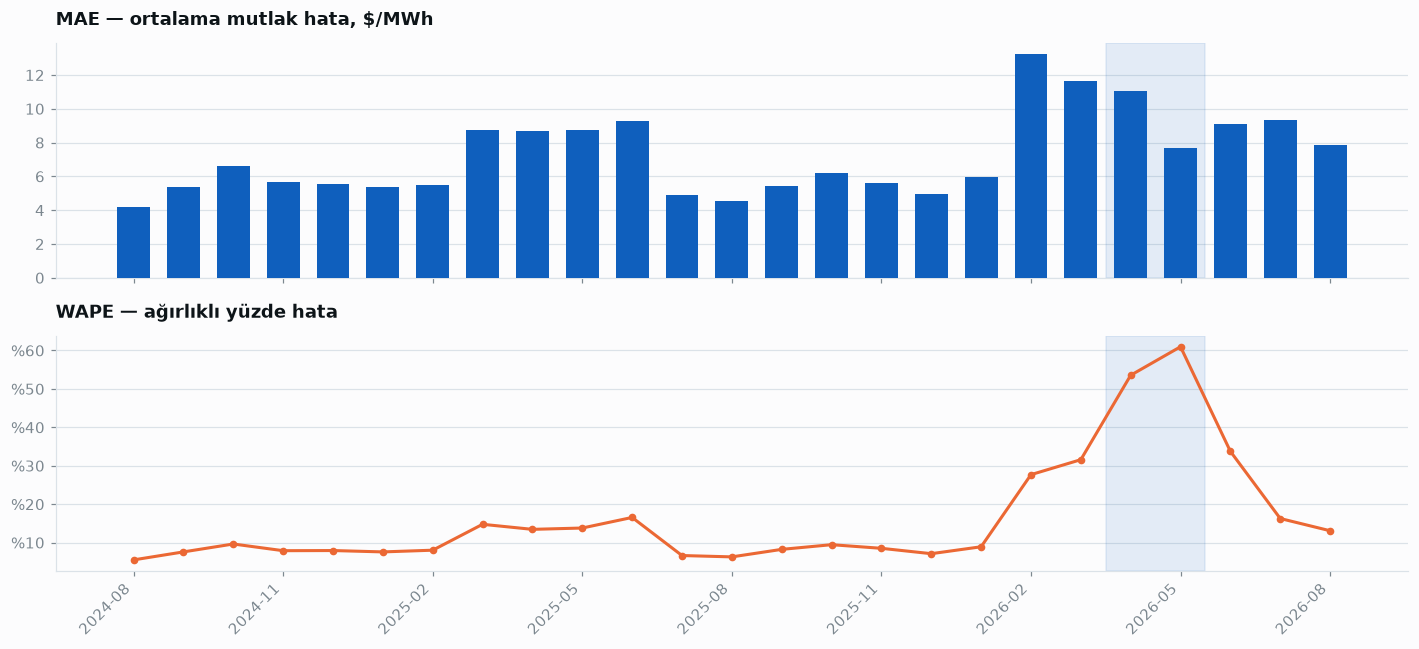

         ort_fiyat    MAE  BIAS  WAPE%  kapsama%
ay                                              
2026-03      36.81  11.62  5.23  31.58     61.83
2026-04      20.66  11.06  4.06  53.55     50.69
2026-05      12.60   7.68  2.09  60.97     62.20
2026-06      26.89   9.07 -1.56  33.75     63.75


In [25]:
aylik_m = mdl.groupby('ay').apply(metrikler, include_groups=False)
aylik_m['n'] = aylik_m['n'].astype(int)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
x = np.arange(len(aylik_m))

ax1.bar(x, aylik_m['MAE'], 0.66, color=ACCENT, zorder=3)
duzen(ax1, 'MAE — ortalama mutlak hata, $/MWh')

ax2.plot(x, aylik_m['WAPE%'], color=WARN, lw=2, marker='o', ms=4, zorder=3)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'%{v:.0f}'))
duzen(ax2, 'WAPE — ağırlıklı yüzde hata')

# Nisan→Mayıs 2026 vurgusu
i4 = list(aylik_m.index).index('2026-04')
for ax in (ax1, ax2):
    ax.axvspan(i4 - 0.5, i4 + 1.5, color=ACCENT, alpha=0.10, zorder=1)

ax2.set_xticks(x[::3]); ax2.set_xticklabels(aylik_m.index[::3], rotation=45, ha='right')
plt.tight_layout(); plt.show()

print(aylik_m.loc['2026-03':'2026-06',
                  ['ort_fiyat', 'MAE', 'BIAS', 'WAPE%', 'kapsama%']].round(2))

> **Bulgu.** Nisan → Mayıs 2026: **MAE \$11,06'dan \$7,68'e düştü, WAPE %53,6'dan %61,0'a
> çıktı.** Model iyileşti, yüzde metriği kötüleşti — çünkü paydadaki ortalama fiyat
> \$20,7'den \$12,6'ya indi.
>
> **Kural:** düşük fiyat rejiminde WAPE ve MAPE ile model kararı verilmez. Karar metriği
> MAE ve BIAS; literatürle kıyas için rMAE.
>
> **İkinci bulgu — BIAS sütunu:** Şubat +9,22 → Mart +5,23 → Nisan +4,06 → Mayıs +2,09 →
> Haziran −1,56. Sapma kalıcı değil; günlük yeniden eğitim onu ~3 ayda kapatıyor.


## 12. Modelin sistematik zayıflığı

Toplam rakamlar modelin en önemli kusurunu gizliyor. Gerçekleşen fiyat dilimine göre
ayrıştırınca ortaya tek yönlü ve düzenli bir sapma çıkıyor.


In [26]:
kenar = [-1e9, 0, 10, 20, 30, 40, 60, 80, 1e9]
etiket = ['= $0', '$0–10', '$10–20', '$20–30', '$30–40', '$40–60', '$60–80', '$80+']
mdl['dilim'] = pd.cut(mdl['px'], bins=kenar, labels=etiket)

dilim = mdl.groupby('dilim', observed=False).apply(metrikler, include_groups=False)
dilim['n'] = dilim['n'].astype(int)
dilim['ort_tahmin'] = mdl.groupby('dilim', observed=False)['pred'].mean()
dilim[['n', 'ort_fiyat', 'ort_tahmin', 'MAE', 'BIAS', 'kapsama%']].round(2)

,n,ort_fiyat,ort_tahmin,MAE,BIAS,kapsama%
dilim,,,,,,
= $0,414,0.00,3.78,3.78,3.78,42.51
$0–10,1363,4.73,13.28,9.47,8.56,43.65
$10–20,486,14.37,25.71,14.46,11.34,47.12
$20–30,571,24.97,33.63,14.37,8.66,58.49
$30–40,1036,35.70,43.50,13.48,7.80,62.64
$40–60,2607,51.18,57.26,10.77,6.08,67.32
$60–80,7186,71.40,70.28,5.63,-1.13,83.30
$80+,3929,84.59,81.35,3.96,-3.25,75.01


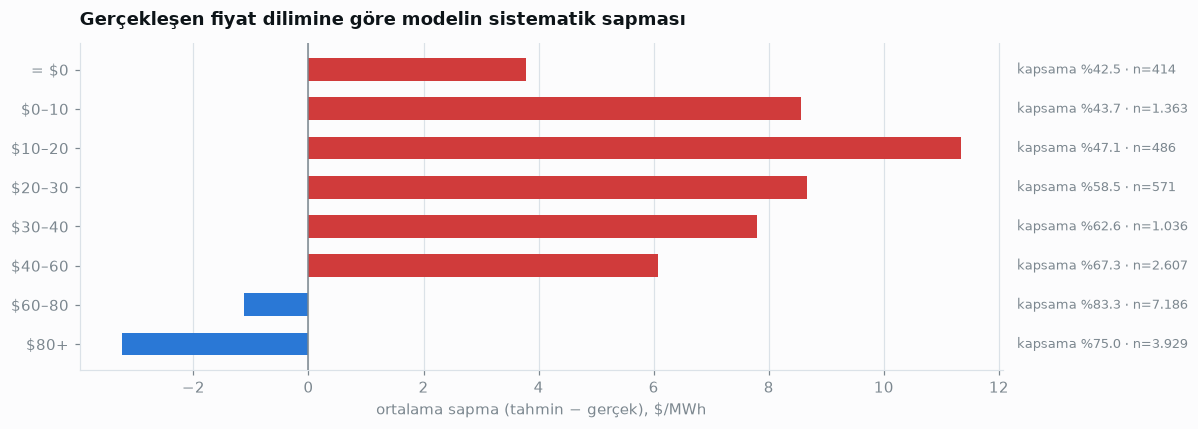

In [27]:
fig, ax = plt.subplots(figsize=(11, 4))
y = np.arange(len(dilim))[::-1]
renkler = [POS if v > 0 else NEG for v in dilim['BIAS']]

ax.barh(y, dilim['BIAS'], 0.58, color=renkler, zorder=3)
ax.axvline(0, color=INK3, lw=1, zorder=4)
ax.set_yticks(y); ax.set_yticklabels(dilim.index)

for yi, (b, k, n) in zip(y, dilim[['BIAS', 'kapsama%', 'n']].values):
    ax.text(ax.get_xlim()[1] * 1.02, yi, f'kapsama %{k:.1f} · n={int(n):,}'.replace(',', '.'),
            va='center', fontsize=8.5, color=INK3)

ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
ax.set_title('Gerçekleşen fiyat dilimine göre modelin sistematik sapması',
             loc='left', pad=12, color=INK)
ax.set_xlabel('ortalama sapma (tahmin − gerçek), $/MWh')
plt.tight_layout(); plt.show()

> **Bulgu.** Fiyat düştükçe model yukarı kaçıyor: \$0–10 diliminde **+\$8,56** — gerçek
> ortalama \$4,73 iken tahmin \$13,28. Belirsizlik bandı da orada çalışmıyor: nominal %80
> olması gereken kapsama **%43,7**.
>
> Bu gürültü değil, ortalamaya çekilme (shrinkage). Ve **sebebi kayıp fonksiyonu değil** —
> log dönüşümü ve örnek ağırlıklandırma denendi, kaldıraç zayıf kaldı. Gerçek sebep
> Bölüm 5'teki bulgu: modelin 2023–2025'ten öğrendiği "yüksek hidro = normal fiyat" kuralı
> 2026'da geçersizleşti.
>
> **Mekanizma:** güneş ve rüzgârın ertesi gün için alt tahmincisi var, **hidronun yok** —
> hidro modele 24 saat gecikmeli giriyor. Şubat–Mayıs 2026 rampasında hidro her gün artarken
> gecikmeli değer arzı eksik gösterdi, model fiyatı yukarı tahmin etti.


## 13. Vaka: 16 Ağustos 2026

Toplam metrikler modelin gerçek davranışını her zaman anlatmaz.


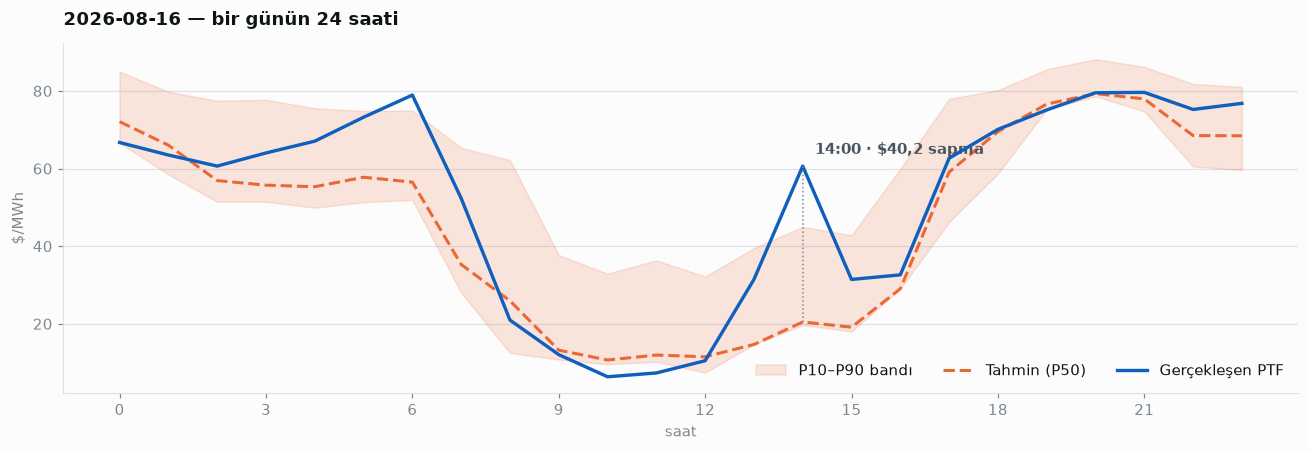

n            24.00
ort_fiyat    52.45
MAE           8.26
BIAS         -6.13
naive_MAE    13.23
rMAE          0.62
sMAPE%       22.87
WAPE%        15.74
kapsama%     79.17

gün içi makas: 12.5 kat ($6.35 → $79.63)


In [28]:
VAKA_TARIH = '2026-08-16'
v = mdl[mdl['target_ts'].dt.strftime('%Y-%m-%d') == VAKA_TARIH].copy()
v['saat'] = v['target_ts'].dt.hour
v = v.sort_values('saat')

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.fill_between(v['saat'], v['p10'], v['p90'], color=WARN, alpha=0.16,
                label='P10–P90 bandı', zorder=2)
ax.plot(v['saat'], v['pred'], color=WARN, lw=2, ls='--', label='Tahmin (P50)', zorder=3)
ax.plot(v['saat'], v['px'], color=ACCENT, lw=2.2, label='Gerçekleşen PTF', zorder=4)

k = v[v['saat'] == 14].iloc[0]
ax.annotate(f"14:00 · ${k['px'] - k['pred']:.1f} sapma".replace('.', ','),
            (14, k['px']), textcoords='offset points', xytext=(8, 8),
            color=INK2, fontsize=9.5, fontweight='bold')
ax.vlines(14, k['pred'], k['px'], color=INK3, lw=1, ls=':', zorder=5)

ax.set_xticks(range(0, 24, 3)); ax.set_xlabel('saat'); ax.legend(ncol=3)
duzen(ax, f'{VAKA_TARIH} — bir günün 24 saati', '$/MWh')
plt.tight_layout(); plt.show()

print(metrikler(v).round(2).to_string())
print(f"\ngün içi makas: {v['px'].max() / v['px'].min():.1f} kat "
      f"(${v['px'].min():.2f} → ${v['px'].max():.2f})")

> **Bulgu.** Model öğle çöküşünü doğru yakaladı (10:00 için \$10,66 tahmin, gerçekleşen
> \$6,35) ve akşam zirvesini de (20:00 için \$79,32, gerçekleşen \$79,53). Kaçırdığı şey
> 13:00–15:00 arasındaki ani geri sıçrama.
>
> Modelin karakteri: **seviyeyi ve günün genel şeklini tutuyor, saatlik keskin rampalarda
> geri kalıyor.**


## Kapanış — bulgular ve sıradaki adımlar

### Doğrulanmış bulgular

| #   | Bulgu                                                                               | Bölüm  |
| --- | ----------------------------------------------------------------------------------- | ------ |
| 1   | Fiyatı belirleyen büyüklük termal ihtiyaç oranı; hidro payı yıllar arası taşınmıyor | 5      |
| 2   | Plato seviyesi gaz referans fiyatından türetilebiliyor (2026: \$70,4 vs \$70,5)     | 6      |
| 3   | 2026 çöküşü güneş değil hidro kaynaklı (%29,8 → %50,4)                              | 4      |
| 4   | Gün içi şekil beş yılda kökten değişti (öğle 0,99 → 0,36)                           | 8      |
| 5   | Model naive'i her rejimde yeniyor (rMAE 0,756) ama ucuz saatlerde yukarı sapıyor    | 10, 12 |

### Doğrulanamayan hipotez

Lisanssız güneşin talebi bastırdığı tezini tüketim profili desteklemedi (Bölüm 9).
Ayrıştırmak için dağıtım seviyesi veri gerekiyor.

### Öncelikli iyileştirmeler

1. **Hidroyu diğer yenilenebilirlerle eşit muamele et** — alt tahmincilere hidro ekle,
   net yükten hidroyu düş, jeotermal + biyokütleyi must-run olarak dahil et.
2. **Termal ihtiyaç oranını açık feature olarak ekle** (Bölüm 5 tanımı).
3. **Ölçüm protokolü:** 1 ve 2'yi birlikte kurup Şubat–Haziran 2026 üzerinde walk-forward
   backtest. Başarı kriteri o dönemin MAE'sini \$11–13 bandından ne kadar indirdiği —
   **WAPE'e bakılmaz**.
4. **Baraj doluluk geçmişini geriye doldur** (DB'de sadece 2026-08 var).

---

**Kaynak:** `reports/tavandan_sifira.html` · üreteci `reports/build_report.py`

**Not:** Bu notebook'un çıktıları kasıtlı olarak kaydedilir. Repoda daha önce 12 deney
sonucu notebook çıktıları temizlendiği için kaybolmuştu.
